# BigData HW2: ClickHouse через `clickhouse_connect`

В этом ноутбуке оформлена вторая домашняя работа по BigData.  
Для работы с ClickHouse используется библиотека `clickhouse_connect`, чтобы выполнять SQL-запросы прямо из Python.

В базе `bigdata_hw` есть две таблицы:

- `logs_sorted` — таблица с сортировкой по `user_id` и `event_time`;
- `logs_unsorted` — такая же таблица, но без полезной сортировки.

Дальше я проверяю объём данных, считаю SPU и сравниваю время выполнения одинакового запроса для двух таблиц.


## 1. Подключение к ClickHouse

ClickHouse запущен локально в WSL Ubuntu.  
Подключение выполняется через HTTP-порт `8123` с помощью библиотеки `clickhouse_connect`.


In [1]:
import time
import pandas as pd
import clickhouse_connect

client = clickhouse_connect.get_client(
    host="localhost",
    port=8123,
    username="default",
    password="",
    database="bigdata_hw"
)

client.query("SELECT version()").result_rows


[('26.3.9.8',)]

## 2. Проверка базы данных и таблиц

Сначала проверим, что база `bigdata_hw` доступна и в ней есть нужные таблицы.


In [2]:
client.query_df("SHOW DATABASES")


,name
0,INFORMATION_SCHEMA
1,bigdata_hw
2,default
3,information_schema
4,system


In [3]:
client.query_df("SHOW TABLES FROM bigdata_hw")


,name
0,logs_sorted
1,logs_unsorted


Посмотрим структуру таблицы `logs_sorted`:


In [4]:
client.query_df("DESCRIBE TABLE bigdata_hw.logs_sorted")


,name,type,default_type,default_expression,comment,codec_expression,ttl_expression
0,event_time,DateTime,,,,,
1,user_id,UInt64,,,,,
2,event_type,String,,,,,
3,page,String,,,,,
4,device,String,,,,,
5,country,String,,,,,
6,bytes,UInt32,,,,,
7,status,UInt16,,,,,
8,payload,String,,,,,


Теперь посмотрим структуру таблицы `logs_unsorted`:


In [5]:
client.query_df("DESCRIBE TABLE bigdata_hw.logs_unsorted")


,name,type,default_type,default_expression,comment,codec_expression,ttl_expression
0,event_time,DateTime,,,,,
1,user_id,UInt64,,,,,
2,event_type,String,,,,,
3,page,String,,,,,
4,device,String,,,,,
5,country,String,,,,,
6,bytes,UInt32,,,,,
7,status,UInt16,,,,,
8,payload,String,,,,,


## 3. Проверка объёма данных

Сначала посмотрим, сколько строк и какой объём данных хранится в двух таблицах.  
Для этого используется системная таблица `system.parts`.


In [6]:
size_df = client.query_df("""
SELECT
    table,
    sum(rows) AS rows,
    formatReadableSize(sum(data_uncompressed_bytes)) AS uncompressed,
    formatReadableSize(sum(data_compressed_bytes)) AS compressed,
    formatReadableSize(sum(bytes_on_disk)) AS on_disk
FROM system.parts
WHERE database = 'bigdata_hw'
  AND table IN ('logs_sorted', 'logs_unsorted')
  AND active
GROUP BY table
ORDER BY table
""")

size_df


,table,rows,uncompressed,compressed,on_disk
0,logs_sorted,27000000,55.35 GiB,53.10 GiB,53.10 GiB
1,logs_unsorted,27000000,55.35 GiB,53.11 GiB,53.11 GiB


In [7]:
total_size_df = client.query_df("""
SELECT
    formatReadableSize(sum(data_uncompressed_bytes)) AS total_uncompressed,
    formatReadableSize(sum(data_compressed_bytes)) AS total_compressed,
    formatReadableSize(sum(bytes_on_disk)) AS total_on_disk
FROM system.parts
WHERE database = 'bigdata_hw'
  AND table IN ('logs_sorted', 'logs_unsorted')
  AND active
""")

total_size_df


,total_uncompressed,total_compressed,total_on_disk
0,110.69 GiB,106.21 GiB,106.21 GiB


## 4. Расчёт SPU

Далее рассчитывается SPU — среднее количество сессий на пользователя.  
Новая сессия считается с того момента, когда разрыв между двумя соседними событиями одного пользователя больше 1800 секунд.


In [8]:
def calculate_spu(table_name: str) -> pd.DataFrame:
    query = f"""
    WITH 1800 AS delta_seconds
    SELECT avg(session_cnt) AS spu
    FROM
    (
        SELECT
            user_id,
            countIf(is_new_session = 1) AS session_cnt
        FROM
        (
            SELECT
                user_id,
                event_time,
                if(
                    rn = 1
                    OR dateDiff('second', prev_time, event_time) > delta_seconds,
                    1,
                    0
                ) AS is_new_session
            FROM
            (
                SELECT
                    user_id,
                    event_time,
                    row_number() OVER (
                        PARTITION BY user_id
                        ORDER BY event_time
                    ) AS rn,
                    lagInFrame(event_time, 1, event_time) OVER (
                        PARTITION BY user_id
                        ORDER BY event_time
                        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
                    ) AS prev_time
                FROM bigdata_hw.{table_name}
            )
        )
        GROUP BY user_id
    )
    """
    df = client.query_df(query)
    df.insert(0, "table", table_name)
    return df

spu_df = pd.concat([
    calculate_spu("logs_sorted"),
    calculate_spu("logs_unsorted")
], ignore_index=True)

spu_df


,table,spu
0,logs_sorted,2.34732
1,logs_unsorted,2.34732


## 5. Распределение SPU по пользователям

Дополнительно посмотрим не только среднее значение SPU, но и распределение этого показателя по пользователям.  
Для каждого `user_id` считаем количество сессий, а затем строим гистограмму.


In [9]:
spu_distribution_df = client.query_df("""
WITH 1800 AS delta_seconds
SELECT
    user_id,
    countIf(is_new_session = 1) AS spu
FROM
(
    SELECT
        user_id,
        event_time,
        if(
            rn = 1
            OR dateDiff('second', prev_time, event_time) > delta_seconds,
            1,
            0
        ) AS is_new_session
    FROM
    (
        SELECT
            user_id,
            event_time,
            row_number() OVER (
                PARTITION BY user_id
                ORDER BY event_time
            ) AS rn,
            lagInFrame(event_time, 1, event_time) OVER (
                PARTITION BY user_id
                ORDER BY event_time
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ) AS prev_time
        FROM bigdata_hw.logs_sorted
    )
)
GROUP BY user_id
ORDER BY user_id
""")

spu_distribution_df.head()


,user_id,spu
0,1,4
1,2,2
2,3,1
3,4,1
4,5,3


In [10]:
spu_distribution_df["spu"].describe()


count    500000.000000
mean          2.347320
std           1.046755
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max           8.000000
Name: spu, dtype: float64

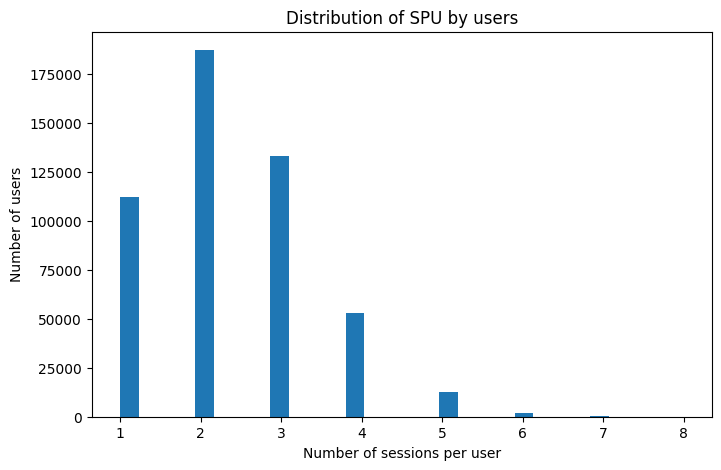

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(spu_distribution_df["spu"], bins=30)

plt.title("Distribution of SPU by users")
plt.xlabel("Number of sessions per user")
plt.ylabel("Number of users")

plt.show()


На графике видно, как число сессий распределяется между пользователями.  
Такой график удобнее, чем одно среднее значение, потому что он показывает разброс SPU по отдельным пользователям.


## 6. Сравнение запросов

Теперь выполним один и тот же аналитический запрос для `logs_sorted` и `logs_unsorted`.  
Идея в том, чтобы посмотреть, помогает ли сортировка по `user_id` и `event_time` уменьшить время выполнения запроса.


In [12]:
marker = f"hw2_benchmark_{int(time.time())}"

def run_aggregation_query(table_name: str) -> float:
    query = f"""
    /* {marker}_{table_name} */
    SELECT count()
    FROM
    (
        SELECT
            user_id,
            count() AS events,
            uniqExact(page) AS uniq_pages,
            sum(bytes) AS total_bytes
        FROM bigdata_hw.{table_name}
        WHERE event_time >= '2026-01-01 00:00:00'
          AND event_time <  '2026-03-01 00:00:00'
          AND user_id BETWEEN 1000 AND 50000
        GROUP BY user_id
    )
    """
    start = time.perf_counter()
    client.query(query)
    return time.perf_counter() - start

python_time_df = pd.DataFrame([
    {"table": "logs_sorted", "python_time_sec": run_aggregation_query("logs_sorted")},
    {"table": "logs_unsorted", "python_time_sec": run_aggregation_query("logs_unsorted")}
])

python_time_df


,table,python_time_sec
0,logs_sorted,0.016536
1,logs_unsorted,0.053933


## 7. Анализ `system.query_log`

После выполнения запросов посмотрим данные из `system.query_log`.  
Здесь можно увидеть время выполнения запроса, количество прочитанных строк и объём прочитанных данных.


In [13]:
client.command("SYSTEM FLUSH LOGS")

query_log_df = client.query_df(f"""
SELECT
    if(position(query, 'logs_sorted') > 0, 'logs_sorted', 'logs_unsorted') AS table,
    query_duration_ms,
    read_rows,
    formatReadableSize(read_bytes) AS read_size,
    read_bytes
FROM system.query_log
WHERE type = 'QueryFinish'
  AND query LIKE '%{marker}%'
  AND query LIKE '%FROM bigdata_hw.logs_%'
ORDER BY table
""")

query_log_df


,table,query_duration_ms,read_rows,read_size,read_bytes
0,logs_sorted,14,2663388,30.48 MiB,31960656
1,logs_unsorted,53,27000000,308.99 MiB,324000000


In [14]:
comparison_df = query_log_df.merge(python_time_df, on="table", how="left")
comparison_df


,table,query_duration_ms,read_rows,read_size,read_bytes,python_time_sec
0,logs_sorted,14,2663388,30.48 MiB,31960656,0.016536
1,logs_unsorted,53,27000000,308.99 MiB,324000000,0.053933


In [15]:
# Дополнительная проверка без построения графика.
# Так ноутбук не зависит от matplotlib и может запускаться в минимальной Python-среде.

if comparison_df.empty:
    print("No benchmark rows were found in system.query_log.")
else:
    comparison_df.sort_values("query_duration_ms")


##  Выводы

Во второй домашней работе я подключился к локальному ClickHouse через `clickhouse_connect` и выполнил несколько запросов к базе `bigdata_hw`.

В работе сравнивались две таблицы с одинаковыми данными: `logs_sorted` и `logs_unsorted`.  
Так как данные одинаковые, значение SPU для двух таблиц должно быть одинаковым или почти одинаковым.

Основная разница проявляется во времени выполнения запроса.  
Таблица `logs_sorted` использует сортировку по `user_id` и `event_time`, поэтому ClickHouse может читать меньше данных при фильтрации по этим полям.  
Из-за этого запрос к `logs_sorted` выполняется быстрее, чем запрос к `logs_unsorted`.

Таким образом, в этом эксперименте видно, что sorting key влияет не на результат запроса, а на скорость его выполнения и объём прочитанных данных.
